# 02 — Schema accuracy, abstention, and prompt comparison

This notebook analyses the main empirical question: whether structured image-schema prompting improves the model's ability to classify literal spatial, metaphorical spatial, and weak-schema control sentences.

It now includes the v2 `schema_present` / `NONE` abstention mechanism and compares:

- `p_direct_schema_v1` vs `p_direct_schema_v2_abstention`;
- `p_structured_roles_v1` vs `p_structured_roles_v2_abstention`;
- provider and model differences;
- schema-family difficulty;
- control false-positive schema rate.

The key methodological question is whether the v2 abstention gate improves controls without reducing performance on literal and metaphorical non-control items.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run these notebooks from the project notebooks/ directory.
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"

RAW_PATH = OUTPUTS_DIR / "raw_responses.jsonl"
PARSED_PATH = OUTPUTS_DIR / "parsed_responses.jsonl"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"
COST_PATH = OUTPUTS_DIR / "cost_log.jsonl"

def read_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} at line {line_no}: {exc}") from exc
    return pd.DataFrame(records)

def safe_read_jsonl(path: Path) -> pd.DataFrame:
    return read_jsonl(path) if path.exists() else pd.DataFrame()

def clean_label(value):
    if pd.isna(value):
        return None
    return str(value).strip()

def norm_prompt_generation(prompt_id):
    if pd.isna(prompt_id):
        return "unknown"
    prompt_id = str(prompt_id)
    if "_v2_" in prompt_id or prompt_id.endswith("_v2"):
        return "v2_abstention"
    if "_v1" in prompt_id:
        return "v1"
    return "unknown"

def safe_accuracy(df: pd.DataFrame, pred_col: str, gold_col: str):
    if df.empty or pred_col not in df.columns or gold_col not in df.columns:
        return None
    sub = df[df[pred_col].notna() & df[gold_col].notna()].copy()
    if sub.empty:
        return None
    return float((sub[pred_col].astype(str) == sub[gold_col].astype(str)).mean())

def safe_rate(series):
    if series is None or len(series) == 0:
        return None
    return float(pd.Series(series).mean())

def pct(x, digits=1):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "NA"
    return f"{100*x:.{digits}f}%"

def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "prompt_id" in out.columns:
        out["prompt_generation"] = out["prompt_id"].map(norm_prompt_generation)
        out["uses_abstention_gate"] = out["prompt_id"].astype(str).str.contains("abstention", case=False, na=False)
    else:
        out["prompt_generation"] = "unknown"
        out["uses_abstention_gate"] = False

    if "sentence_type" in out.columns:
        out["gold_schema_present"] = np.where(out["sentence_type"].eq("control_weak_schema"), "no", "yes")
    else:
        out["gold_schema_present"] = np.nan

    if "main_image_schema" in out.columns:
        out["predicted_schema_present_from_schema"] = np.where(out["main_image_schema"].eq("NONE"), "no", "yes")
    else:
        out["predicted_schema_present_from_schema"] = np.nan

    if "schema_present" not in out.columns:
        out["schema_present"] = out["predicted_schema_present_from_schema"]

    if "literal_or_metaphorical" not in out.columns:
        out["literal_or_metaphorical"] = np.nan

    if "expected_literal_or_metaphorical" not in out.columns:
        out["expected_literal_or_metaphorical"] = np.nan

    if "main_image_schema" not in out.columns:
        out["main_image_schema"] = np.nan

    if "expected_schema_primary" not in out.columns:
        out["expected_schema_primary"] = np.nan

    out["is_control"] = out["sentence_type"].eq("control_weak_schema") if "sentence_type" in out.columns else False
    out["is_structured_json"] = out["parse_status"].eq("parsed") if "parse_status" in out.columns else False
    out["control_correct"] = out["is_control"] & out["literal_or_metaphorical"].eq("control") & out["main_image_schema"].eq("NONE")
    out["control_false_positive_schema"] = out["is_control"] & out["main_image_schema"].notna() & ~out["main_image_schema"].eq("NONE")
    out["schema_present_correct"] = out["schema_present"].eq(out["gold_schema_present"])
    out["primary_schema_correct"] = out["main_image_schema"].eq(out["expected_schema_primary"])
    out["lm_correct"] = out["literal_or_metaphorical"].eq(out["expected_literal_or_metaphorical"])
    return out

def summarize_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=group_cols + [
            "n", "parse_rate", "schema_present_accuracy", "primary_schema_accuracy",
            "literal_metaphorical_accuracy", "control_accuracy",
            "control_false_positive_schema_rate", "non_control_lm_accuracy"
        ])
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        parsed = g[g["parse_status"].eq("parsed")] if "parse_status" in g.columns else g
        controls = parsed[parsed["is_control"]]
        non_controls = parsed[~parsed["is_control"]]
        row = dict(zip(group_cols, keys))
        row.update({
            "n": len(g),
            "parsed_n": len(parsed),
            "parse_rate": len(parsed) / len(g) if len(g) else None,
            "schema_present_accuracy": safe_rate(parsed["schema_present_correct"]) if len(parsed) else None,
            "primary_schema_accuracy": safe_accuracy(parsed, "main_image_schema", "expected_schema_primary"),
            "literal_metaphorical_accuracy": safe_accuracy(parsed, "literal_or_metaphorical", "expected_literal_or_metaphorical"),
            "control_accuracy": safe_rate(controls["control_correct"]) if len(controls) else None,
            "control_false_positive_schema_rate": safe_rate(controls["control_false_positive_schema"]) if len(controls) else None,
            "non_control_lm_accuracy": safe_rate(non_controls["lm_correct"]) if len(non_controls) else None,
        })
        rows.append(row)
    return pd.DataFrame(rows)

def display_percent_table(df: pd.DataFrame, percent_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x) if x is not None else "NA")
    return out

In [2]:
parsed = add_derived_columns(read_jsonl(PARSED_PATH))
structured = parsed[parsed["parse_status"].eq("parsed")].copy()

print(f"Total parsed records: {len(parsed)}")
print(f"Structured JSON records: {len(structured)}")
display(structured.head())

Total parsed records: 9000
Structured JSON records: 7200


,run_key,run_index,provider,model_id,model_name,prompt_id,prompt_family,prompt_version,condition_id,condition_family,...,uses_abstention_gate,gold_schema_present,predicted_schema_present_from_schema,is_control,is_structured_json,control_correct,control_false_positive_schema,schema_present_correct,primary_schema_correct,lm_correct
620,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,600,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,True,False,False,True,True,True
621,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,601,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,True,False,False,True,True,True
622,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,602,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,True,False,False,True,True,True
623,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,603,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,True,False,False,True,True,True
624,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,604,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,yes,yes,False,True,False,False,True,False,True


In [3]:
# Overall structured metrics
overall = summarize_group(structured, ["prompt_generation"])
display(display_percent_table(overall, [
    "parse_rate", "schema_present_accuracy", "primary_schema_accuracy",
    "literal_metaphorical_accuracy", "control_accuracy",
    "control_false_positive_schema_rate", "non_control_lm_accuracy"
]))

,prompt_generation,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,v1,3600,3600,100.0%,85.8%,76.1%,85.6%,57.3%,42.7%,99.6%
1,v2_abstention,3600,3600,100.0%,92.8%,85.1%,92.6%,78.4%,21.6%,99.6%


In [4]:
# Main comparison by prompt_id
by_prompt = summarize_group(structured, ["prompt_id", "prompt_family", "prompt_generation"])
display(display_percent_table(by_prompt, [
    "parse_rate", "schema_present_accuracy", "primary_schema_accuracy",
    "literal_metaphorical_accuracy", "control_accuracy",
    "control_false_positive_schema_rate", "non_control_lm_accuracy"
]))

,prompt_id,prompt_family,prompt_generation,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,p_direct_schema_v1,direct_schema,v1,1800,1800,100.0%,80.8%,71.9%,80.8%,41.9%,58.1%,99.9%
1,p_direct_schema_v2_abstention,direct_schema,v2_abstention,1800,1800,100.0%,92.7%,85.9%,92.7%,78.5%,21.5%,99.8%
2,p_structured_roles_v1,structured_role_based,v1,1800,1800,100.0%,90.7%,80.3%,90.5%,72.7%,27.3%,99.3%
3,p_structured_roles_v2_abstention,structured_role_based,v2_abstention,1800,1800,100.0%,92.8%,84.3%,92.4%,78.3%,21.7%,99.4%


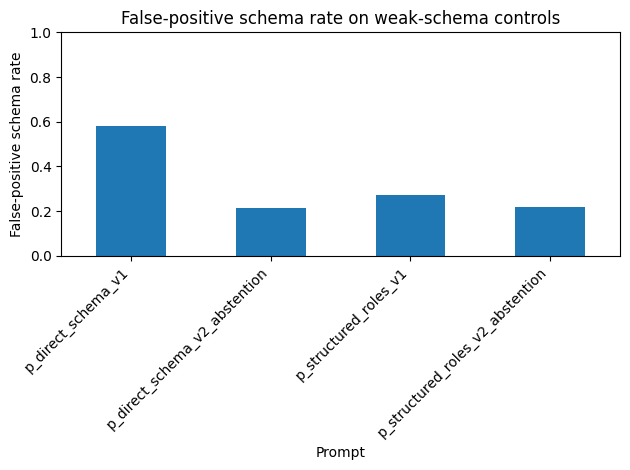

In [5]:
# Control false positive rate by prompt
plot_df = by_prompt.dropna(subset=["control_false_positive_schema_rate"]).copy()
if not plot_df.empty:
    ax = plot_df.plot(kind="bar", x="prompt_id", y="control_false_positive_schema_rate", legend=False)
    ax.set_title("False-positive schema rate on weak-schema controls")
    ax.set_xlabel("Prompt")
    ax.set_ylabel("False-positive schema rate")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

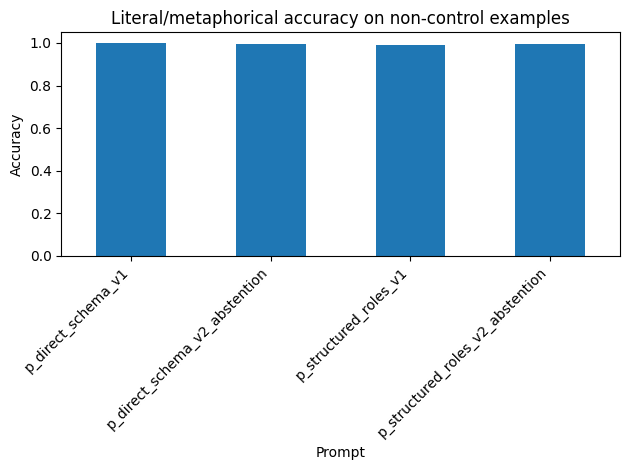

In [6]:
# Non-control literal/metaphorical accuracy by prompt
plot_df = by_prompt.dropna(subset=["non_control_lm_accuracy"]).copy()
if not plot_df.empty:
    ax = plot_df.plot(kind="bar", x="prompt_id", y="non_control_lm_accuracy", legend=False)
    ax.set_title("Literal/metaphorical accuracy on non-control examples")
    ax.set_xlabel("Prompt")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [7]:
# Sentence-type comparison
by_sentence = summarize_group(structured, ["prompt_id", "sentence_type"])
display(display_percent_table(by_sentence, [
    "schema_present_accuracy", "primary_schema_accuracy",
    "literal_metaphorical_accuracy",
    "control_accuracy", "control_false_positive_schema_rate", "non_control_lm_accuracy"
]))

,prompt_id,sentence_type,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,p_direct_schema_v1,control_weak_schema,594,594,1.0,41.9%,41.9%,41.9%,41.9%,58.1%,NA
1,p_direct_schema_v1,literal_spatial,603,603,1.0,100.0%,82.9%,99.8%,NA,NA,99.8%
2,p_direct_schema_v1,metaphorical_spatial,603,603,1.0,100.0%,90.5%,100.0%,NA,NA,100.0%
3,p_direct_schema_v2_abstention,control_weak_schema,594,594,1.0,78.5%,78.5%,78.5%,78.5%,21.5%,NA
4,p_direct_schema_v2_abstention,literal_spatial,603,603,1.0,100.0%,86.4%,100.0%,NA,NA,100.0%
5,p_direct_schema_v2_abstention,metaphorical_spatial,603,603,1.0,99.5%,92.9%,99.5%,NA,NA,99.5%
6,p_structured_roles_v1,control_weak_schema,594,594,1.0,72.7%,72.7%,72.7%,72.7%,27.3%,NA
7,p_structured_roles_v1,literal_spatial,603,603,1.0,99.0%,77.9%,98.5%,NA,NA,98.5%
8,p_structured_roles_v1,metaphorical_spatial,603,603,1.0,100.0%,90.2%,100.0%,NA,NA,100.0%
9,p_structured_roles_v2_abstention,control_weak_schema,594,594,1.0,78.3%,78.3%,78.3%,78.3%,21.7%,NA


In [8]:
# Provider/model comparison
by_model_prompt = summarize_group(structured, ["provider", "model_id", "prompt_id"])
display(display_percent_table(by_model_prompt, [
    "schema_present_accuracy", "primary_schema_accuracy", "literal_metaphorical_accuracy",
    "control_accuracy", "control_false_positive_schema_rate", "non_control_lm_accuracy"
]))

,provider,model_id,prompt_id,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,600,600,1.0,68.5%,61.0%,68.5%,4.5%,95.5%,100.0%
1,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,600,600,1.0,92.2%,85.8%,92.2%,76.3%,23.7%,100.0%
2,anthropic,claude_sonnet_4_6,p_structured_roles_v1,600,600,1.0,91.2%,80.7%,91.2%,73.2%,26.8%,100.0%
3,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,600,600,1.0,90.8%,81.3%,90.3%,72.2%,27.8%,99.3%
4,google,gemini_2_5_flash,p_direct_schema_v1,600,600,1.0,76.8%,70.5%,76.8%,29.8%,70.2%,100.0%
5,google,gemini_2_5_flash,p_direct_schema_v2_abstention,600,600,1.0,87.2%,81.2%,87.2%,61.1%,38.9%,100.0%
6,google,gemini_2_5_flash,p_structured_roles_v1,600,600,1.0,82.7%,72.8%,82.7%,47.5%,52.5%,100.0%
7,google,gemini_2_5_flash,p_structured_roles_v2_abstention,600,600,1.0,88.5%,80.2%,88.5%,65.2%,34.8%,100.0%
8,openai,openai_gpt_5_4_mini,p_direct_schema_v1,600,600,1.0,97.2%,84.3%,97.0%,91.4%,8.6%,99.8%
9,openai,openai_gpt_5_4_mini,p_direct_schema_v2_abstention,600,600,1.0,98.8%,90.8%,98.8%,98.0%,2.0%,99.3%


In [9]:
# Schema-family difficulty on schema-present, non-control examples.
non_control = structured[~structured["is_control"]].copy()
by_schema = summarize_group(non_control, ["expected_schema_primary", "prompt_id"])
display(display_percent_table(by_schema, [
    "schema_present_accuracy", "primary_schema_accuracy", "literal_metaphorical_accuracy", "non_control_lm_accuracy"
]))

,expected_schema_primary,prompt_id,n,parsed_n,parse_rate,schema_present_accuracy,primary_schema_accuracy,literal_metaphorical_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy
0,BLOCKAGE,p_direct_schema_v1,198,198,1.0,100.0%,96.5%,99.5%,None,None,99.5%
1,BLOCKAGE,p_direct_schema_v2_abstention,198,198,1.0,100.0%,97.5%,100.0%,None,None,100.0%
2,BLOCKAGE,p_structured_roles_v1,198,198,1.0,98.5%,95.5%,98.5%,None,None,98.5%
3,BLOCKAGE,p_structured_roles_v2_abstention,198,198,1.0,100.0%,99.0%,97.0%,None,None,97.0%
4,CONTAINER,p_direct_schema_v1,207,207,1.0,100.0%,91.8%,100.0%,None,None,100.0%
5,CONTAINER,p_direct_schema_v2_abstention,207,207,1.0,100.0%,89.9%,100.0%,None,None,100.0%
6,CONTAINER,p_structured_roles_v1,207,207,1.0,100.0%,77.3%,100.0%,None,None,100.0%
7,CONTAINER,p_structured_roles_v2_abstention,207,207,1.0,100.0%,85.5%,100.0%,None,None,100.0%
8,FORCE,p_direct_schema_v1,198,198,1.0,100.0%,85.4%,100.0%,None,None,100.0%
9,FORCE,p_direct_schema_v2_abstention,198,198,1.0,100.0%,87.9%,100.0%,None,None,100.0%


In [10]:
# Confusion matrix for primary schema by prompt.
for prompt_id, g in structured.groupby("prompt_id"):
    g2 = g[g["expected_schema_primary"].notna() & g["main_image_schema"].notna()]
    if g2.empty:
        continue
    print(f"\nPrimary-schema confusion matrix: {prompt_id}")
    display(pd.crosstab(g2["expected_schema_primary"], g2["main_image_schema"],
                        rownames=["gold"], colnames=["predicted"], dropna=False))


Primary-schema confusion matrix: p_direct_schema_v1


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,191,0,7,0,0,0,0
CONTAINER,0,190,0,0,17,0,0
FORCE,0,0,169,0,24,0,5
NONE,6,157,38,249,134,2,8
SOURCE_PATH_GOAL,0,2,0,0,205,0,0
SUPPORT_BALANCE,0,2,33,0,0,156,7
VERTICALITY,0,1,0,0,53,9,135



Primary-schema confusion matrix: p_direct_schema_v2_abstention


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,193,0,5,0,0,0,0
CONTAINER,2,186,0,0,18,0,1
FORCE,0,0,174,0,16,0,8
NONE,6,68,26,466,20,0,8
SOURCE_PATH_GOAL,0,3,0,3,201,0,0
SUPPORT_BALANCE,0,0,16,0,0,181,1
VERTICALITY,0,0,0,0,43,9,146



Primary-schema confusion matrix: p_structured_roles_v1


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,189,0,6,3,0,0,0
CONTAINER,0,160,0,0,46,0,1
FORCE,0,0,167,0,26,0,5
NONE,7,58,35,432,56,0,6
SOURCE_PATH_GOAL,0,0,0,0,207,0,0
SUPPORT_BALANCE,0,0,27,3,0,168,0
VERTICALITY,0,0,2,0,64,9,123



Primary-schema confusion matrix: p_structured_roles_v2_abstention


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,196,0,2,0,0,0,0
CONTAINER,0,177,0,0,27,0,3
FORCE,0,0,175,0,20,0,3
NONE,6,56,35,465,26,0,6
SOURCE_PATH_GOAL,0,0,0,1,206,0,0
SUPPORT_BALANCE,0,0,27,0,2,169,0
VERTICALITY,0,0,1,0,59,9,129


In [11]:
# v1 vs v2 paired comparison where comparable run dimensions exist.
# This compares direct_schema v1 vs v2 by provider/model/condition/sentence/repetition.
comparable_cols = ["provider", "model_id", "condition_id", "sentence_id", "repetition_index"]

direct = structured[structured["prompt_family"].eq("direct_schema")].copy()
if not direct.empty:
    direct["is_v2"] = direct["prompt_id"].str.contains("v2", na=False)
    v1 = direct[~direct["is_v2"]][comparable_cols + ["control_correct", "control_false_positive_schema", "primary_schema_correct", "lm_correct"]]
    v2 = direct[direct["is_v2"]][comparable_cols + ["control_correct", "control_false_positive_schema", "primary_schema_correct", "lm_correct"]]
    paired = v1.merge(v2, on=comparable_cols, suffixes=("_v1", "_v2"))
    print(f"Paired direct-schema v1/v2 records: {len(paired)}")
    if not paired.empty:
        paired_summary = pd.DataFrame({
            "metric": ["control_correct", "control_false_positive_schema", "primary_schema_correct", "lm_correct"],
            "v1_mean": [
                paired["control_correct_v1"].mean(),
                paired["control_false_positive_schema_v1"].mean(),
                paired["primary_schema_correct_v1"].mean(),
                paired["lm_correct_v1"].mean(),
            ],
            "v2_mean": [
                paired["control_correct_v2"].mean(),
                paired["control_false_positive_schema_v2"].mean(),
                paired["primary_schema_correct_v2"].mean(),
                paired["lm_correct_v2"].mean(),
            ],
        })
        paired_summary["delta_v2_minus_v1"] = paired_summary["v2_mean"] - paired_summary["v1_mean"]
        display(display_percent_table(paired_summary, ["v1_mean", "v2_mean", "delta_v2_minus_v1"]))

Paired direct-schema v1/v2 records: 1800


,metric,v1_mean,v2_mean,delta_v2_minus_v1
0,control_correct,13.8%,25.9%,12.1%
1,control_false_positive_schema,19.2%,7.1%,-12.1%
2,primary_schema_correct,71.9%,85.9%,14.0%
3,lm_correct,80.8%,92.7%,11.9%


## Interpretation guide

A successful v2 abstention mechanism should show:

1. higher control accuracy;
2. lower control false-positive schema rate;
3. no meaningful reduction in literal/metaphorical accuracy on non-control records;
4. ideally, improved `schema_present_accuracy`.

If these conditions are met, the key finding is that poor control performance was at least partly prompt-induced over-attribution, not a general failure of semantic interpretation.